In [56]:
import pandas as pd
import numpy as np

# load your CSV
df = pd.read_csv("../data/public_datasets/res/public_progressive_cae.csv")

df.head()

,stage_id,seen_classes,probe_class,n_train,n_test_seen,n_test_unseen,test_unseen_ratio,accuracy,f1_macro,cade_detected,...,mateen_score_unseen,gidx_score_unseen,pe_score_unseen,lmt_score_unseen,cade_score_norm,chen_score_norm,mateen_score_norm,gidx_score_norm,pe_score_norm,lmt_score_norm
0,1,Benign | HTTP Flood,OS Scan,8000,1600,400,0.2,0.7995,0.599658,False,...,7.278474e-30,0.201857,0.061681,100.950097,1.000000,1.000000,0.000002,0.000000,0.000000,0.477362
1,2,Benign | HTTP Flood | OS Scan,Command Injection,12000,1600,400,0.2,0.6345,0.541700,False,...,6.767373e-11,0.206111,0.639784,103.448957,0.282189,0.579623,0.002593,0.472946,0.414786,1.000000
2,3,Benign | HTTP Flood | OS Scan | Command Injection,BrowserHijacking,16000,1600,400,0.2,0.5880,0.531695,False,...,1.922511e-21,0.219566,0.911568,49.559013,0.094917,0.000000,0.000000,0.761590,0.633543,0.544868
3,4,Benign | HTTP Flood | OS Scan | Command Inject...,SQL Injection,20000,1600,400,0.2,0.5500,0.519136,False,...,5.113840e-04,0.213417,1.144364,35.144088,0.000000,0.016661,0.025498,0.866817,0.842392,0.000000
4,5,Benign | HTTP Flood | OS Scan | Command Inject...,XSS,24000,1600,400,0.2,0.4900,0.474153,False,...,2.961248e-01,0.225880,1.250520,45.743732,0.054344,0.118457,1.000000,1.000000,1.000000,0.014110


In [57]:
methods = ["cade", "chen", "gidx", "pe", "lmt"]

for m in methods:
    benign_col = f"{m}_score_benign"
    seen_col = f"{m}_score_seen_mean"
    unseen_col = f"{m}_score_unseen"
    delta_col = f"{m}_delta"
    deltaratio_col = f"{m}_deltaratio"

    if seen_col in df.columns and unseen_col in df.columns:
        df[delta_col] = df[unseen_col] - df[seen_col]
        df[deltaratio_col] = df[delta_col]
    else:
        df[delta_col] = np.nan

    

df.head()

,stage_id,seen_classes,probe_class,n_train,n_test_seen,n_test_unseen,test_unseen_ratio,accuracy,f1_macro,cade_detected,...,cade_delta,cade_deltaratio,chen_delta,chen_deltaratio,gidx_delta,gidx_deltaratio,pe_delta,pe_deltaratio,lmt_delta,lmt_deltaratio
0,1,Benign | HTTP Flood,OS Scan,8000,1600,400,0.2,0.7995,0.599658,False,...,2.297583,2.297583,-0.668329,-0.668329,0.001828,0.001828,0.052821,0.052821,78.292487,78.292487
1,2,Benign | HTTP Flood | OS Scan,Command Injection,12000,1600,400,0.2,0.6345,0.541700,False,...,0.470008,0.470008,-0.490162,-0.490162,-0.005821,-0.005821,0.399333,0.399333,74.477489,74.477489
2,3,Benign | HTTP Flood | OS Scan | Command Injection,BrowserHijacking,16000,1600,400,0.2,0.5880,0.531695,False,...,-0.150421,-0.150421,-0.390395,-0.390395,-0.005485,-0.005485,0.466866,0.466866,11.559161,11.559161
3,4,Benign | HTTP Flood | OS Scan | Command Inject...,SQL Injection,20000,1600,400,0.2,0.5500,0.519136,False,...,-0.195693,-0.195693,-0.246881,-0.246881,-0.016686,-0.016686,0.482335,0.482335,2.347594,2.347594
4,5,Benign | HTTP Flood | OS Scan | Command Inject...,XSS,24000,1600,400,0.2,0.4900,0.474153,False,...,0.118962,0.118962,-0.074592,-0.074592,-0.009777,-0.009777,0.414765,0.414765,14.941299,14.941299


In [58]:
def make_stage_label(row):
    classes = [x.strip() for x in str(row["seen_classes"]).split("|")]
    if len(classes) <= 1:
        return "Baseline"
    attacks = [c for c in classes if c != "Benign"]
    if len(attacks) == 0:
        return "Baseline"
    return f"S{len(attacks)} = Benign + Attack(1..{len(attacks)})"

df["stage_label"] = df.apply(make_stage_label, axis=1)

df[["stage_id", "seen_classes", "stage_label", "probe_class"]]

,stage_id,seen_classes,stage_label,probe_class
0,1,Benign | HTTP Flood,S1 = Benign + Attack(1..1),OS Scan
1,2,Benign | HTTP Flood | OS Scan,S2 = Benign + Attack(1..2),Command Injection
2,3,Benign | HTTP Flood | OS Scan | Command Injection,S3 = Benign + Attack(1..3),BrowserHijacking
3,4,Benign | HTTP Flood | OS Scan | Command Inject...,S4 = Benign + Attack(1..4),SQL Injection
4,5,Benign | HTTP Flood | OS Scan | Command Inject...,S5 = Benign + Attack(1..5),XSS


In [59]:
rows = []

for _, r in df.iterrows():
    for m in methods:
        row = {
            "Stage": r["stage_label"],
            "Stage_ID": r["stage_id"],
            "Probe": r["probe_class"],
            "Drift Method": m.upper(),
            "Acc": r["accuracy"],
            "F1": r["f1_macro"],
            "Benign": r.get(f"{m}_score_benign", np.nan),
            "Seen": r.get(f"{m}_score_seen_mean", np.nan),
            "Unseen": r.get(f"{m}_score_unseen", np.nan),
            "Delta": r.get(f"{m}_delta", np.nan),
        }
        rows.append(row)

table_long = pd.DataFrame(rows)
table_long.head(20)

,Stage,Stage_ID,Probe,Drift Method,Acc,F1,Benign,Seen,Unseen,Delta
0,S1 = Benign + Attack(1..1),1,OS Scan,CADE,0.7995,0.599658,1.366189,1.072959,3.370542,2.297583
1,S1 = Benign + Attack(1..1),1,OS Scan,CHEN,0.7995,0.599658,1.465062,1.741274,1.072944,-0.668329
2,S1 = Benign + Attack(1..1),1,OS Scan,GIDX,0.7995,0.599658,0.200003,0.200029,0.201857,0.001828
3,S1 = Benign + Attack(1..1),1,OS Scan,PE,0.7995,0.599658,0.008266,0.008861,0.061681,0.052821
4,S1 = Benign + Attack(1..1),1,OS Scan,LMT,0.7995,0.599658,22.943652,22.657609,100.950097,78.292487
5,S2 = Benign + Attack(1..2),2,Command Injection,CADE,0.6345,0.541700,0.541889,0.861749,1.331757,0.470008
6,S2 = Benign + Attack(1..2),2,Command Injection,CHEN,0.6345,0.541700,1.320419,1.434275,0.944112,-0.490162
7,S2 = Benign + Attack(1..2),2,Command Injection,GIDX,0.6345,0.541700,0.215344,0.211932,0.206111,-0.005821
8,S2 = Benign + Attack(1..2),2,Command Injection,PE,0.6345,0.541700,0.554831,0.240451,0.639784,0.399333
9,S2 = Benign + Attack(1..2),2,Command Injection,LMT,0.6345,0.541700,30.401346,28.971468,103.448957,74.477489


In [60]:
rows = []

for _, r in df.iterrows():
    for m in methods:
        row = {
            "Stage": r["stage_label"],
            "Stage_ID": r["stage_id"],
            "Probe": r["probe_class"],
            "Drift Method": m.upper(),
            "Acc": r["accuracy"],
            "F1": r["f1_macro"],
            "Benign": r.get(f"{m}_score_benign", np.nan),
            "Seen": r.get(f"{m}_score_seen_mean", np.nan),
            "Unseen": r.get(f"{m}_score_unseen", np.nan),
            "Delta": r.get(f"{m}_delta", np.nan),
        }
        rows.append(row)

table_long = pd.DataFrame(rows)

num_cols = ["Acc", "F1", "Benign", "Seen", "Unseen", "Delta"]
table_long[num_cols] = table_long[num_cols].round(2)


table_long

,Stage,Stage_ID,Probe,Drift Method,Acc,F1,Benign,Seen,Unseen,Delta
0,S1 = Benign + Attack(1..1),1,OS Scan,CADE,0.80,0.60,1.37,1.07,3.37,2.30
1,S1 = Benign + Attack(1..1),1,OS Scan,CHEN,0.80,0.60,1.47,1.74,1.07,-0.67
2,S1 = Benign + Attack(1..1),1,OS Scan,GIDX,0.80,0.60,0.20,0.20,0.20,0.00
3,S1 = Benign + Attack(1..1),1,OS Scan,PE,0.80,0.60,0.01,0.01,0.06,0.05
4,S1 = Benign + Attack(1..1),1,OS Scan,LMT,0.80,0.60,22.94,22.66,100.95,78.29
5,S2 = Benign + Attack(1..2),2,Command Injection,CADE,0.63,0.54,0.54,0.86,1.33,0.47
6,S2 = Benign + Attack(1..2),2,Command Injection,CHEN,0.63,0.54,1.32,1.43,0.94,-0.49
7,S2 = Benign + Attack(1..2),2,Command Injection,GIDX,0.63,0.54,0.22,0.21,0.21,-0.01
8,S2 = Benign + Attack(1..2),2,Command Injection,PE,0.63,0.54,0.55,0.24,0.64,0.40
9,S2 = Benign + Attack(1..2),2,Command Injection,LMT,0.63,0.54,30.40,28.97,103.45,74.48


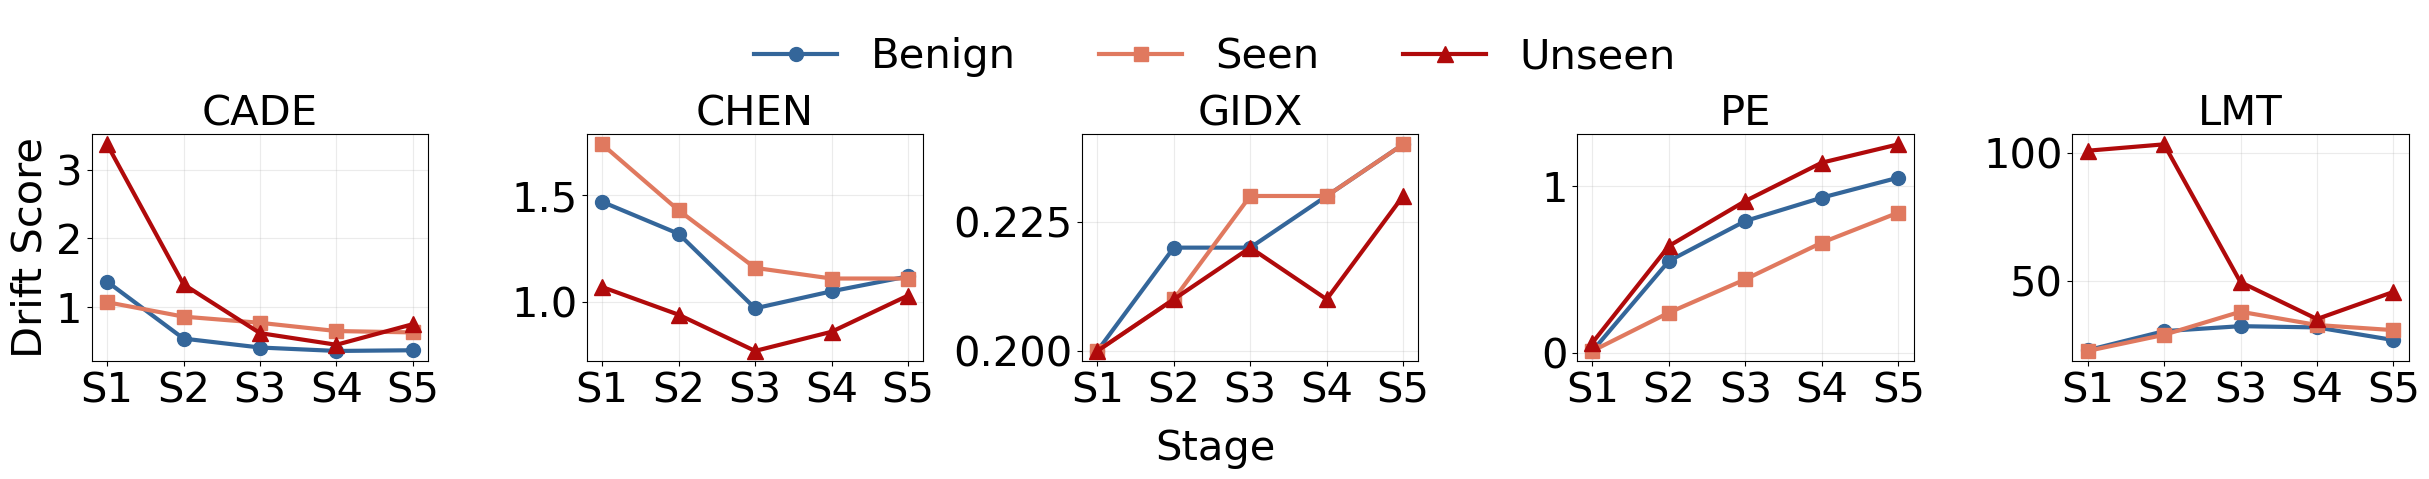

,Stage_ID,Stage
0,1,S1 = Benign + Attack(1..1)
1,2,S2 = Benign + Attack(1..2)
2,3,S3 = Benign + Attack(1..3)
3,4,S4 = Benign + Attack(1..4)
4,5,S5 = Benign + Attack(1..5)


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# Assumes you already have: table_long
# Columns expected:
# Stage, Stage_ID, Probe, Drift Method, Acc, F1, Benign, Seen, Unseen, Delta
# =========================================================

# Example if you need to load it from csv:
# table_long = pd.read_csv("progressive_stage_method_table.csv")

# ---------------------------------------------------------
# Style
# ---------------------------------------------------------
FIG_W, FIG_H = 5, 6
FONT_MAIN = 30#28
FONT_EXTRA = 28 #26

COLORS = {
    "dark_blue": "#34669A",
    "orange": "#E0795F",
    "light_blue": "#86BAD4",
    "light_orange": "#F5B783",
    "pink": "#F4C5C3",
    "red": "#B00A0B",
}

plt.rcParams["font.size"] = FONT_MAIN
plt.rcParams["axes.labelsize"] = FONT_MAIN
plt.rcParams["xtick.labelsize"] = FONT_MAIN
plt.rcParams["ytick.labelsize"] = FONT_MAIN
plt.rcParams["legend.fontsize"] = FONT_MAIN

# ---------------------------------------------------------
# Clean and order data
# ---------------------------------------------------------
dfp = table_long.copy()

# drop baseline rows if present
dfp = dfp[dfp["Probe"].astype(str) != "None"].copy()

# standardize method names
dfp["Drift Method"] = dfp["Drift Method"].astype(str).str.upper()

# keep only methods with full conditional values
dfp = dfp.dropna(subset=["Benign", "Seen", "Unseen"])

# choose method order here
method_order = ["CADE", "CHEN", "GIDX", "PE", "LMT"]
method_order = [m for m in method_order if m in dfp["Drift Method"].unique()]

# order stages
stage_order = (
    dfp[["Stage_ID", "Stage"]]
    .drop_duplicates()
    .sort_values("Stage_ID")
)
stage_ids = stage_order["Stage_ID"].tolist()
stage_labels = stage_order["Stage"].tolist()

# ---------------------------------------------------------
# Build 1 x n subplot
# ---------------------------------------------------------
n_methods = len(method_order)
fig, axes = plt.subplots(1, n_methods, figsize=(FIG_W * n_methods, FIG_H), sharex=True)

if n_methods == 1:
    axes = [axes]

for ax, method in zip(axes, method_order):
    sub = dfp[dfp["Drift Method"] == method].copy()
    sub = sub.sort_values("Stage_ID")

    # align to full stage order in case a method is missing a stage
    sub = (
        pd.DataFrame({"Stage_ID": stage_ids})
        .merge(sub, on="Stage_ID", how="left")
    )

    x = np.arange(len(stage_ids))

    ax.plot(
        x, sub["Benign"].values,
        marker="o", linewidth=3, markersize=10,
        color=COLORS["dark_blue"], label="Benign"
    )
    ax.plot(
        x, sub["Seen"].values,
        marker="s", linewidth=3, markersize=10,
        color=COLORS["orange"], label="Seen"
    )
    ax.plot(
        x, sub["Unseen"].values,
        marker="^", linewidth=3, markersize=12,
        color=COLORS["red"], label="Unseen"
    )

    ax.set_title(method, fontsize=FONT_MAIN)
    ax.set_xticks(x)
    ax.set_xticklabels([f"S{i+1}" for i in range(len(stage_ids))], rotation=0)
    ax.grid(alpha=0.25)

    if ax is axes[0]:
        ax.set_ylabel("Drift Score", fontsize=FONT_MAIN)

# single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=FONT_MAIN)

fig.supxlabel("Stage", fontsize=FONT_MAIN, y=0.2)
plt.tight_layout(rect=[0, 0.08, 1, 0.90])
plt.savefig("ciciot23.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# Optional: print stage mapping
# ---------------------------------------------------------
display(stage_order.reset_index(drop=True))